In [48]:
import numpy as np
import xarray as xr
import netCDF4 as nc


In [18]:
def generate_dates(years = [2021], tag = "400", months = [(1,31), (2,28), (3,31), (4,30)]):

    labels = []
    files = []

    for y in years:
        labels.append([])
        for month in months:
            m, d = month
            if y%4 == 0 and m == 2:
                d = 29
            for i in range(1, d+1):
                if i<10:
                    labels[-1].append(f"{y}0{m}0{i}")
                else:
                    labels[-1].append(f"{y}0{m}{i}")
    
    for list_labels in labels:
        files.append([])
        for label in list_labels:
            files[-1].append(f"/cluster/work/math/camlab-data/experimental/external/nasa_humidity/MERRA2_{tag}.tavg1_2d_flx_Nx.{label}.nc4")

    return files


def load_file(file_path, X = 158, Y = 125, s = 128, var = 'QLML', times = [0]):
    ds = xr.open_dataset(file_path, engine="netcdf4")
    data = ds[var]
    
    slices = np.zeros((0,s,s))
    for t in times:
        _slice = data.isel(time=t)
        _slice = _slice[::-1]
        _slice = np.array(_slice[X:X+s, Y:Y+s])
        slices = np.concatenate((slices, _slice.reshape((1,s,s))))

    ds.close()
    return slices
    

In [58]:
import copy
data2 = copy.deepcopy(data)

In [77]:
len(data2)

6552

In [59]:
#months = [(1,31), (2,28), (3,31), (4,30), (5,31), (6,30), (7,31), (8,31), (9,30), (10,31), (11,30), (12,31)]
months = [(4,30), (5,31), (6,30)]

years = [2023]
files = generate_dates(years, tag = "400", months = months)[0]

In [60]:
#ULML - u-velocity
#VLML - v-velocity
#TLML - temp
#RHOA - rho
#QLML - Humidity
#PBLH - B Layer

X = 158
Y = 125
s = 128
times = np.arange(0,24,1)

vars = ['RHOA', "ULML", "VLML", "TLML", "QLML", "PBLH"]
C = len(vars)

data = np.zeros((0, C, s, s))

for j, file in enumerate(files):
    data_ = np.zeros((len(times),C, s, s))
    for i, var in enumerate(vars):
        slices = load_file(file, X = X, Y = Y, s = s, var = var, times = times)
        data_[:,i] = slices
    data = np.concatenate((data, data_))


    if j%10 == 0:
        print(j, 365)
        

0 365
10 365
20 365
30 365
40 365
50 365
60 365
70 365
80 365
90 365


In [62]:
data.shape[0], 2184/24

(2184, 91.0)

In [64]:
chunk_sizes = (1, 1, s, s)

with nc.Dataset(f"/cluster/work/math/braonic/data/merra2_{years[0]}_91d_alltime_rho_u_v_T_humidity_cbl.nc", 'w', format='NETCDF4') as dataset:
    # Create dimensions
    dataset.createDimension('member', data.shape[0])
    dataset.createDimension('c', data.shape[1])
    dataset.createDimension('x', data.shape[2])
    dataset.createDimension('y', data.shape[3])
    

    # Create variable
    var = dataset.createVariable('data', 'f4', ('member', 'c', 'x', 'y'),
                                 chunksizes=chunk_sizes)

    # Write data
    var[:] = data

In [80]:
 np.random.choice(np.arange(2184-48), size=32)
#a = [1121, 1770, 1034, 1125, 2092,  210,  497,  995,  436, 1915, 1154, 910, 1771,  816, 1064,  564, 1796, 1388, 1197,  501, 2051,  287, 1776,  685,  898,   57,  120,  892, 1644,  320, 2140, 1803]
#print(a)

a = [154, 1069,  395, 1006,  174, 1305, 1940, 1055, 1070, 1497, 1719, 1416, 1714, 1965, 1011,  655, 2120,  749,  630,  744, 1218, 1367, 1843,  397, 1157,   92,  279,  791,  243, 1469, 2080, 1656]

array([ 154, 1069,  395, 1006,  174, 1305, 1940, 1055, 1070, 1497, 1719,
       1416, 1714, 1965, 1011,  655, 2120,  749,  630,  744, 1218, 1367,
       1843,  397, 1157,   92,  279,  791,  243, 1469, 2080, 1656])

In [76]:
mean = []
std = []
for c in range(5):
    m = np.mean(data[:,c])
    s = np.std(data[:,c])
    print(c, m, s)
    mean.append(m)
    std.append(s)
print(mean)
print(std)

0 1.176800148225227 0.06960757019280928
1 -0.09746223033859434 5.797809116228757
2 0.38355840950182857 5.208725633417532
3 292.3969831074931 7.728686887287443
4 0.011588789298511086 0.005013801095853864
[1.176800148225227, -0.09746223033859434, 0.38355840950182857, 292.3969831074931, 0.011588789298511086]
[0.06960757019280928, 5.797809116228757, 5.208725633417532, 7.728686887287443, 0.005013801095853864]


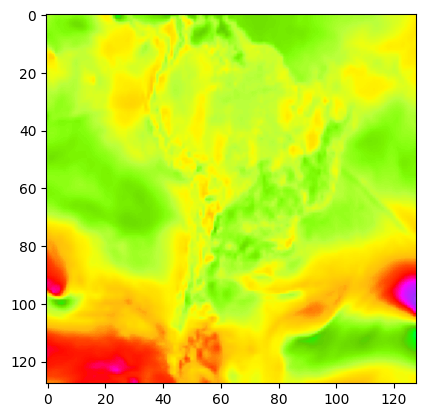

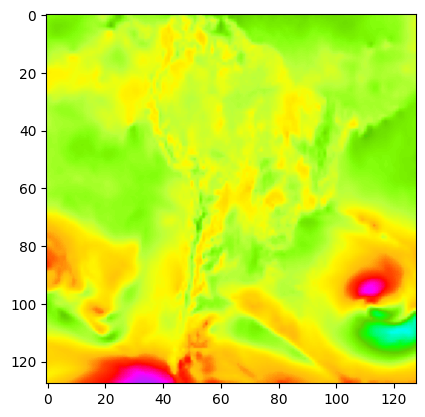

In [74]:
import matplotlib.pyplot as plt

c = 1
id = 76
plt.imshow(data[id,c],cmap = "gist_ncar", vmin = 1.2*np.min(data[:,c]), vmax = 0.8*np.max(data[:,c]))
plt.show()
plt.imshow(data[id + 100,c],cmap = "gist_ncar", vmin = 1.2*np.min(data[:,c]), vmax = 0.8*np.max(data[:,c]))